# Accessing SnowEx Data using the snowexsql database

---

## Overview

The [SnowExSQL database](https://github.com/SnowEx/snowexsql) is a PostgreSQL/PostGIS database hosted on AWS, holding snow observations from NASA SnowEx field campaigns spanning 2017–2023. It contains snow pit profiles, manual depth transects, ground-penetrating radar (GPR), snow microstructure (SMP), and more.

This tutorial introduces the **SnowEx Lambda client** — the current recommended way to access the database. The Lambda client uses a public HTTPS endpoint, so you do not need AWS credentials, a VPN, or any special configuration. Database security is handled behind the scenes by AWS.

This tutorial covers:

1. Connecting to the SnowEx database
2. Discovering what data is available
3. Querying data by geographic area of interest
4. Filtering by campaign and year
5. Point data and layer data: understanding the difference

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Introduction to Pandas](https://foundations.projectpythia.org/core/pandas/pandas/) | Necessary | |
| [Introduction to GeoPandas](https://geopandas.org/en/stable/docs/user_guide.html) | Helpful | Familiarity with GeoDataFrames |
| NASA SnowEx field campaigns | Helpful | See [Field Campaigns Overview](snowex_data_overview.ipynb) |

- **Time to learn**: ~30 minutes

---

## Imports

In [29]:
from datetime import date

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box, Point

from snowexsql.lambda_client import SnowExLambdaClient

## Connecting to the SnowEx Database

The `SnowExLambdaClient` connects to the SnowEx database through a public AWS Lambda Function URL. There is nothing to configure — just instantiate the client and go.

In [30]:
client = SnowExLambdaClient()

# Get the two main measurement classes
classes = client.get_measurement_classes()
PointMeasurements = classes['PointMeasurements']
LayerMeasurements = classes['LayerMeasurements']

# Verify the connection
result = client.test_connection()
print(f"Connected: {result.get('connected', False)}")

Connected: True


:::{note}
The two main data classes are:
- **`PointMeasurements`** — single values at single geographic coordinates (e.g., snow depth from a magnaprobe)
- **`LayerMeasurements`** — values at specific depths within the snowpack (e.g., snow temperature profiles in snow pits)

:::

## Discovering What Data Is Available

Before querying, it's useful to explore what measurement types and campaigns are in the database. Each class exposes `all_*` properties that return lists of available values.

In [31]:
print("Layer measurement types:", LayerMeasurements.all_types)

Layer measurement types: ['density', 'grain_size', 'grain_type', 'hand_hardness', 'manual_wetness', 'comments', 'permittivity', 'liquid_water_content', 'snow_temperature', 'force', 'sample_signal', 'reflectance', 'specific_surface_area', 'equivalent_diameter']


In [32]:
print("Point measurement types:", PointMeasurements.all_types)

Point measurement types: ['two_way_travel', 'depth', 'swe', 'density']


In [102]:
print("Available instruments:", PointMeasurements.all_instruments)

Available instruments: ['camera', 'gpr', 'magnaprobe', 'mesa', 'pit ruler']


Other discovery properties follow the same pattern. For example,
`LayerMeasurements.all_dates` returns every distinct measurement date,
`all_observers` returns observer names, and `all_dois` returns citable
dataset identifiers. These are useful for understanding the full scope
of the database before constructing a query.

## Point Data and Layer Data: Understanding the Difference

The two data types have different structures:

| | PointMeasurements | LayerMeasurements |
|---|---|---|
| **Table** | `points` | `layers` |
| **What it represents** | A single value at a single location | A value at a specific depth within the snowpack |
| **`value` column type** | Float (numeric) | Text (requires conversion) |
| **Geometry** | Direct on each record | From the parent `Site` record |
| **Example data** | Magnaprobe snow depths, GPR travel times | Snow temperature profiles, density profiles, grain size |

## Querying Data by Area of Interest

A common use case is: *"I have a region of interest — what SnowEx data exists there?"*

Both `PointMeasurements` and `LayerMeasurements` support `from_area()`, which accepts a [Shapely](https://shapely.readthedocs.io/) polygon and returns a [GeoDataFrame](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html) of all matching records.

### Layer Data

Here we query snow temperature profiles collected in the Boise Basin, Idaho area.

In [34]:
# Define a bounding box in WGS84 (longitude/latitude)
bbox = box(minx=-116.14, miny=43.73, maxx=-116.04, maxy=43.8)
bbox_gdf = gpd.GeoDataFrame([1], geometry=[bbox], crs='EPSG:4326')

df_layer = LayerMeasurements.from_area(
    shp=bbox,
    date_greater_equal=date(2020, 1, 1),
    date_less_equal=date(2022, 12, 30),
    crs=4326,
    type='snow_temperature',
    limit=600,
    verbose=True,
)
print(f"Retrieved {len(df_layer)} records")
df_layer.head()

Retrieved 586 records


,depth,bottom_depth,value,site_name,site_description,slope_angle,aspect,air_temp,total_depth,weather_description,...,date,geom,type,units,type_derived,instrument_name,instrument_model,instrument_specifications,geom_wkt,geometry
0,80.0,None,0.0,IDBRLO_20200304_1210,None,19.0,135.0,5.8,90.0,"scattered clouds, light wind, sunny",...,2020-03-04T19:10:00+00:00,0101000020e6100000990d32c9c8075dc08a1f63ee5ade...,snow_temperature,deg c,False,Digital Thermometer,None,None,POINT(-116.12163 43.73715),POINT (-116.12163 43.73715)
1,70.0,None,0.0,IDBRLO_20200304_1210,None,19.0,135.0,5.8,90.0,"scattered clouds, light wind, sunny",...,2020-03-04T19:10:00+00:00,0101000020e6100000990d32c9c8075dc08a1f63ee5ade...,snow_temperature,deg c,False,Digital Thermometer,None,None,POINT(-116.12163 43.73715),POINT (-116.12163 43.73715)
2,60.0,None,0.0,IDBRLO_20200304_1210,None,19.0,135.0,5.8,90.0,"scattered clouds, light wind, sunny",...,2020-03-04T19:10:00+00:00,0101000020e6100000990d32c9c8075dc08a1f63ee5ade...,snow_temperature,deg c,False,Digital Thermometer,None,None,POINT(-116.12163 43.73715),POINT (-116.12163 43.73715)
3,50.0,None,0.0,IDBRLO_20200304_1210,None,19.0,135.0,5.8,90.0,"scattered clouds, light wind, sunny",...,2020-03-04T19:10:00+00:00,0101000020e6100000990d32c9c8075dc08a1f63ee5ade...,snow_temperature,deg c,False,Digital Thermometer,None,None,POINT(-116.12163 43.73715),POINT (-116.12163 43.73715)
4,40.0,None,0.0,IDBRLO_20200304_1210,None,19.0,135.0,5.8,90.0,"scattered clouds, light wind, sunny",...,2020-03-04T19:10:00+00:00,0101000020e6100000990d32c9c8075dc08a1f63ee5ade...,snow_temperature,deg c,False,Digital Thermometer,None,None,POINT(-116.12163 43.73715),POINT (-116.12163 43.73715)


:::{note}
`verbose=True` returns additional metadata columns including site name, date, instrument, and environmental conditions at each pit site.
:::

:::{warning}
By default, queries that would return more than 1000 records raise a `LargeQueryCheckException`. Always include a `limit` parameter. If you intentionally need more records, pass `limit=N` with the number you want.
:::

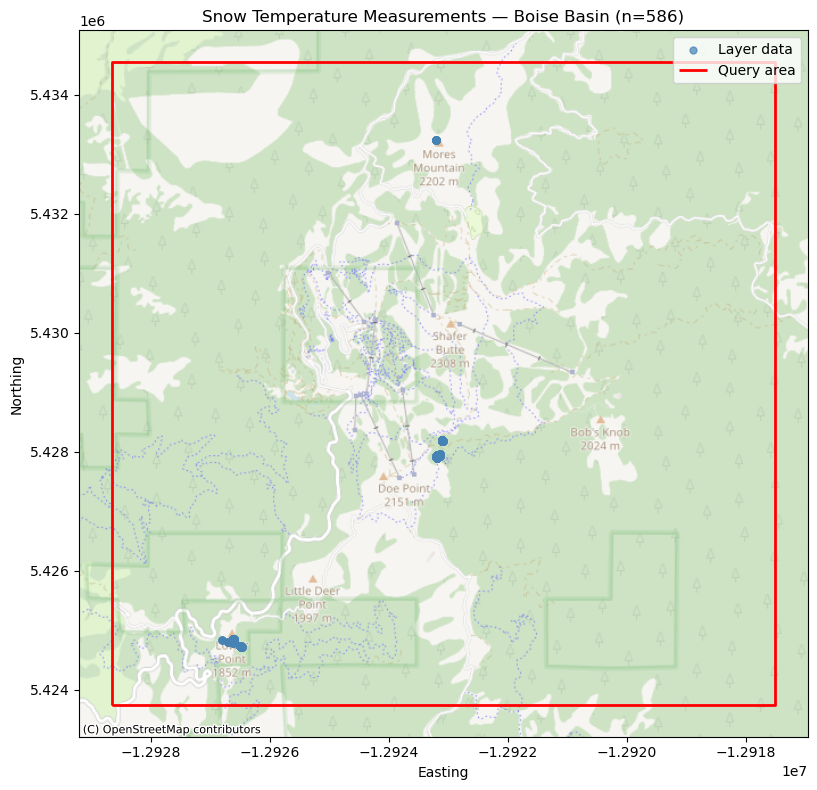

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))

df_layer.to_crs(epsg=3857).plot(
    ax=ax, color='steelblue', markersize=25, alpha=0.7, label='Layer data'
)
bbox_gdf.to_crs(epsg=3857).boundary.plot(
    ax=ax, color='red', linewidth=2, label='Query area'
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.6)
ax.set_title(f'Snow Temperature Measurements — Boise Basin (n={len(df_layer)})')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
ax.legend()
plt.tight_layout()
plt.show()

### Layer Depth Profile

Because `LayerMeasurements.value` is stored as `Text`, we must convert it to numeric before plotting or computing statistics. Here we visualize the snow temperature profile data from Boise Basin as a boxplot by depth band.

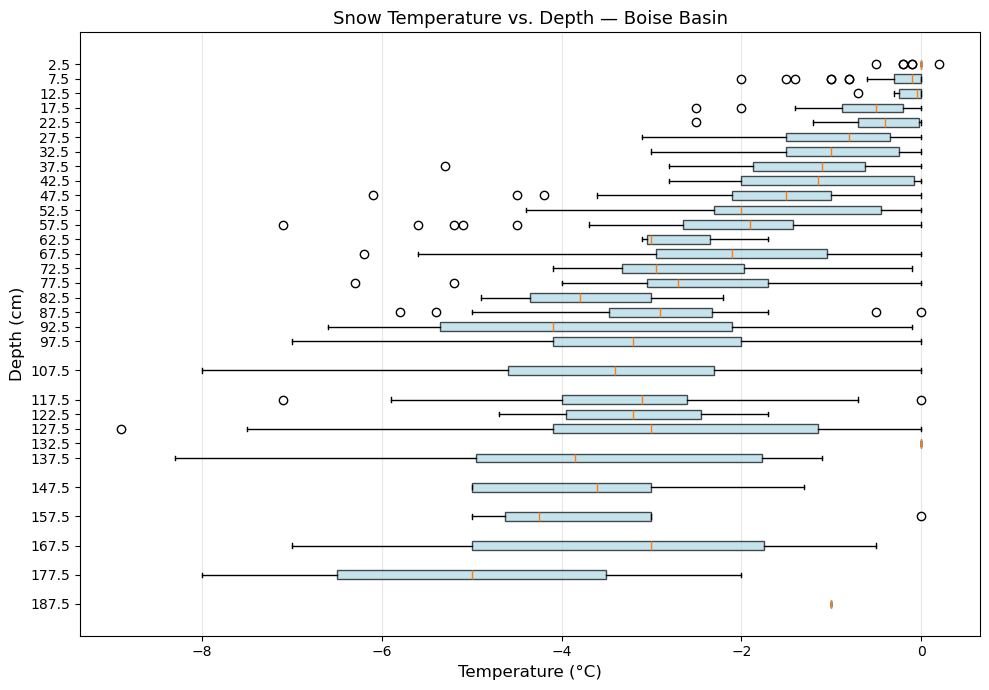

In [36]:
# Convert value to numeric (required for LayerMeasurements)
df_layer['value'] = pd.to_numeric(df_layer['value'], errors='coerce')
df_layer = df_layer.dropna(subset=['value', 'depth'])

# Create 5 cm depth bands
bin_width = 5.0
bins = np.arange(
    np.floor(df_layer['depth'].min()),
    np.ceil(df_layer['depth'].max()) + bin_width,
    bin_width,
)
df_layer['depth_band'] = pd.cut(
    df_layer['depth'],
    bins=bins,
    labels=bins[:-1] + bin_width / 2,
    include_lowest=True,
)
depth_bands = sorted(df_layer['depth_band'].dropna().unique())
data_by_band = [
    df_layer[df_layer['depth_band'] == b]['value'].values for b in depth_bands
]

fig, ax = plt.subplots(figsize=(10, 7))
bp = ax.boxplot(
    data_by_band, positions=depth_bands, vert=False,
    patch_artist=True, widths=3.0,
)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.invert_yaxis()
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Depth (cm)', fontsize=12)
ax.set_title('Snow Temperature vs. Depth — Boise Basin', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Point Data

Now we query snow depth point measurements on Grand Mesa, Colorado.

In [37]:
bbox_gm = box(minx=-108.195487, miny=39.031819, maxx=-108.189329, maxy=39.036568)
bbox_gm_gdf = gpd.GeoDataFrame([1], geometry=[bbox_gm], crs='EPSG:4326')

df_point = PointMeasurements.from_area(
    shp=bbox_gm,
    crs=4326,
    type='depth',
    limit=5000,
)
print(f"Retrieved {len(df_point)} records")
df_point.head()

Retrieved 5000 records


,id,value,datetime,elevation,geom,geometry
0,1264906,101.096736,2020-01-28T16:15:49+00:00,3040.469,0101000020e6100000f79fcd87370c5bc02fbc2d616684...,POINT (-108.19089 39.03437)
1,1264907,101.096736,2020-01-28T16:15:49+00:00,3040.460,0101000020e61000001b65f788370c5bc0d6bd28616684...,POINT (-108.19089 39.03437)
2,1264908,101.096736,2020-01-28T16:15:49+00:00,3040.451,0101000020e6100000ca61088a370c5bc0b78d22616684...,POINT (-108.19089 39.03437)
3,1264909,101.096736,2020-01-28T16:15:49+00:00,3040.442,0101000020e6100000835c0d8b370c5bc0a17008616684...,POINT (-108.19089 39.03437)
4,1264910,101.096736,2020-01-28T16:15:49+00:00,3040.434,0101000020e6100000c88ef98b370c5bc0c521ed606684...,POINT (-108.19089 39.03437)


`verbose=True` returns richer metadata for point measurements — campaign name,
instrument, and observer — useful for attribution and cross-referencing.

In [38]:
df_point_v = PointMeasurements.from_area(
    shp=bbox_gm,
    crs=4326,
    type='depth',
    limit=5,
    verbose=True,
)
df_point_v[['value', 'campaign_name', 'instrument_name', 'observer_name']]

,value,campaign_name,instrument_name,observer_name
0,120.585263,Grand Mesa,gpr,Tate Meehan
1,119.367230,Grand Mesa,gpr,Tate Meehan
2,119.367230,Grand Mesa,gpr,Tate Meehan
3,119.367230,Grand Mesa,gpr,Tate Meehan
4,119.367230,Grand Mesa,gpr,Tate Meehan


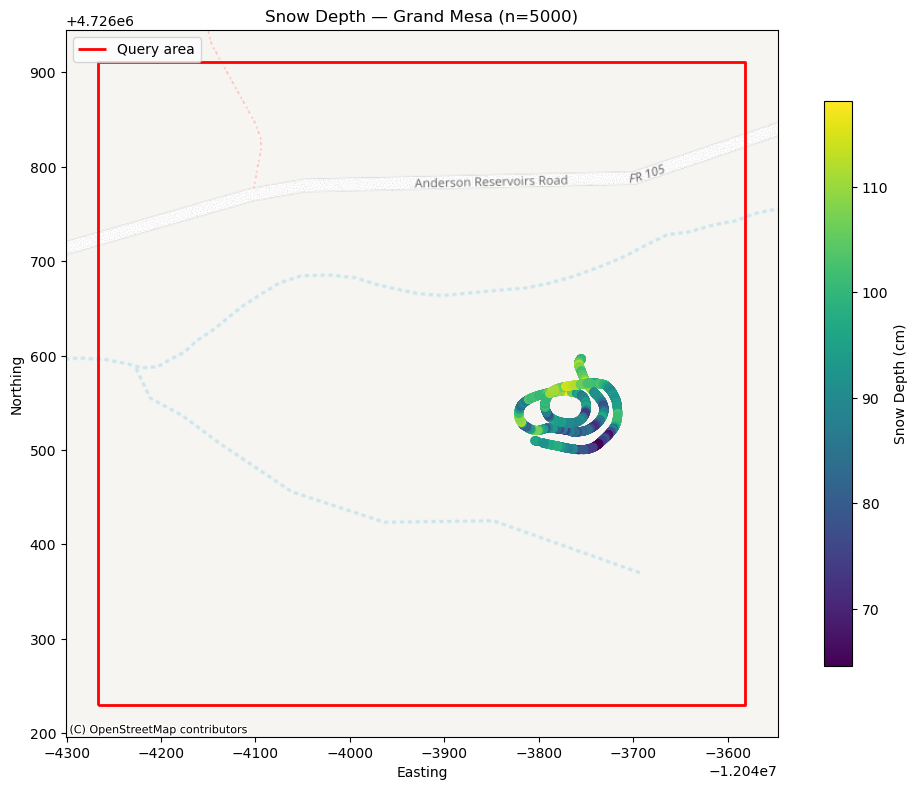

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))

df_point.to_crs(epsg=3857).plot(
    ax=ax,
    column='value',
    cmap='viridis',
    markersize=30,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Snow Depth (cm)', 'shrink': 0.8},
)
bbox_gm_gdf.to_crs(epsg=3857).boundary.plot(
    ax=ax, color='red', linewidth=2, label='Query area'
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.6)
ax.set_title(f'Snow Depth — Grand Mesa (n={len(df_point)})')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

A histogram shows the distribution of snow depths across the queried area.

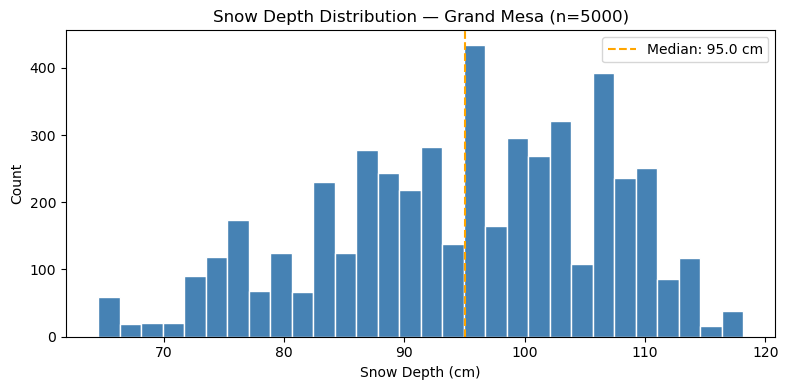

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_point['value'].dropna(), bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Snow Depth (cm)')
ax.set_ylabel('Count')
ax.set_title(f'Snow Depth Distribution — Grand Mesa (n={len(df_point)})')
ax.axvline(df_point['value'].median(), color='orange', linestyle='--',
           label=f"Median: {df_point['value'].median():.1f} cm")
ax.legend()
plt.tight_layout()
plt.show()

### Querying by Point and Radius

If you have a specific site location rather than a bounding box, pass a
`Point` geometry and a `buffer` radius (in the units of the CRS — degrees
for EPSG:4326, meters for a projected CRS).

In [41]:
# Center point of the Grand Mesa query area (lon, lat)
site_pt = Point(-108.192, 39.034)

df_pt_buf = PointMeasurements.from_area(
    pt=site_pt,
    buffer=0.005,   # ~500 m in degrees at this latitude
    crs=4326,
    type='depth',
    limit=1000,
)
print(f"Retrieved {len(df_pt_buf)} records within radius")
df_pt_buf.head()

Retrieved 1000 records within radius


,id,value,datetime,elevation,geom,geometry
0,1264978,99.878703,2020-01-28T16:15:51+00:00,3040.731,0101000020e610000081a765bb370c5bc023015b096684...,POINT (-108.1909 39.03436)
1,1264979,101.096736,2020-01-28T16:15:51+00:00,3040.737,0101000020e610000066d39cbc370c5bc02285b1066684...,POINT (-108.1909 39.03436)
2,1264980,101.096736,2020-01-28T16:15:52+00:00,3040.744,0101000020e61000006163e0bd370c5bc004a208046684...,POINT (-108.1909 39.03436)
3,1264981,101.096736,2020-01-28T16:15:52+00:00,3040.749,0101000020e61000007f5524bf370c5bc0d26a4c016684...,POINT (-108.1909 39.03436)
4,1264982,101.096736,2020-01-28T16:15:52+00:00,3040.754,0101000020e610000063815bc0370c5bc0b4eea2fe6584...,POINT (-108.1909 39.03436)


:::{note}
For meter-accurate radii, reproject your point to a local UTM CRS first
(e.g. EPSG:26912 for UTM Zone 12N), then pass `crs=26912` and `buffer=500`
(meters).
:::

## Filtering by Campaign and Year

When you already know which SnowEx campaign or time period you're interested in, use `from_filter()` to query the entire database without specifying a geographic area.

We can list all the campaigns currently stored in the database:

In [42]:
print("Campaigns in the database:", LayerMeasurements.all_campaigns)

Campaigns in the database: ['North Slope', '2021 Timeseries', 'Alaska 2023', 'Fairbanks', '2020 Timeseries', 'Grand Mesa']


In [43]:
df_campaign = PointMeasurements.from_filter(
    campaign='Alaska 2023',
    type='depth',
    limit=1000,
)
print(f"Retrieved {len(df_campaign)} records from Alaska 2023 campaign")
df_campaign.head()

Retrieved 1000 records from Alaska 2023 campaign


,id,value,datetime,elevation,geom,geometry
0,3842641,79.4,2023-03-08T00:00:00+00:00,276.12,0101000020e610000092cc196b517162c073eb4f39ab49...,POINT (-147.54119 65.15108)
1,3842642,80.1,2023-03-08T00:00:00+00:00,276.11,0101000020e610000054a3886e517162c01066b93bab49...,POINT (-147.54119 65.15108)
2,3842643,80.8,2023-03-08T00:00:00+00:00,276.09,0101000020e61000002c57f771517162c07b03233eab49...,POINT (-147.54119 65.15108)
3,3842644,80.1,2023-03-08T00:00:00+00:00,276.08,0101000020e61000007aff6575517162c0d8aa8c40ab49...,POINT (-147.54119 65.15108)
4,3842645,80.8,2023-03-08T00:00:00+00:00,276.08,0101000020e6100000cba09f78517162c0ddb02043ab49...,POINT (-147.5412 65.15108)


### Filter by Date Range

In [44]:
df_year = LayerMeasurements.from_filter(
    date_greater_equal=date(2020, 1, 1),
    date_less_equal=date(2020, 12, 31),
    type='density',
    limit=500,
)
print(f"Retrieved {len(df_year)} density records from 2020")
df_year.head()

Retrieved 500 density records from 2020


,id,depth,bottom_depth,value,geom,geometry
0,82399,94.0,84.0,98.0,0101000020e6100000ab77d672a6085bc02cca5c1ce483...,POINT (-108.13516 39.0304)
1,82400,84.0,74.0,149.0,0101000020e6100000ab77d672a6085bc02cca5c1ce483...,POINT (-108.13516 39.0304)
2,82401,74.0,64.0,212.0,0101000020e6100000ab77d672a6085bc02cca5c1ce483...,POINT (-108.13516 39.0304)
3,82402,64.0,54.0,223.0,0101000020e6100000ab77d672a6085bc02cca5c1ce483...,POINT (-108.13516 39.0304)
4,82403,54.0,44.0,255.0,0101000020e6100000ab77d672a6085bc02cca5c1ce483...,POINT (-108.13516 39.0304)


### Snow Water Equivalent (SWE)

Snow water equivalent is one of the primary variables SnowEx was designed
to measure. It is available as a `PointMeasurements` type. Here we demonstrate
querying Alaska swe data for a specific date range:

In [100]:
df_swe = PointMeasurements.from_filter(
    type='swe',
    campaign='Alaska 2023',
    date_greater_equal=date(2023, 3, 7),
    date_less_equal=date(2023, 3, 8),
    limit=5000,
    verbose=False,
)
print(f"Retrieved {len(df_swe)} SWE records")
df_swe.head()

Retrieved 5000 SWE records


,id,value,datetime,elevation,geom,geometry
0,4364929,117.0,2023-03-07T00:00:00+00:00,144.82,0101000020e6100000a960e086167762c02a0aba3d6837...,POINT (-147.7215 64.86574)
1,4364930,120.0,2023-03-07T00:00:00+00:00,144.84,0101000020e6100000e625138b167762c03c078b3c6837...,POINT (-147.7215 64.86574)
2,4364931,117.0,2023-03-07T00:00:00+00:00,144.85,0101000020e61000006943528f167762c0e9b17c3b6837...,POINT (-147.7215 64.86574)
3,4364932,122.0,2023-03-07T00:00:00+00:00,144.86,0101000020e610000090c08b93167762c0d09f5e3a6837...,POINT (-147.72151 64.86574)
4,4364933,125.0,2023-03-07T00:00:00+00:00,144.86,0101000020e6100000e889b897167762c0d5561f396837...,POINT (-147.72151 64.86574)


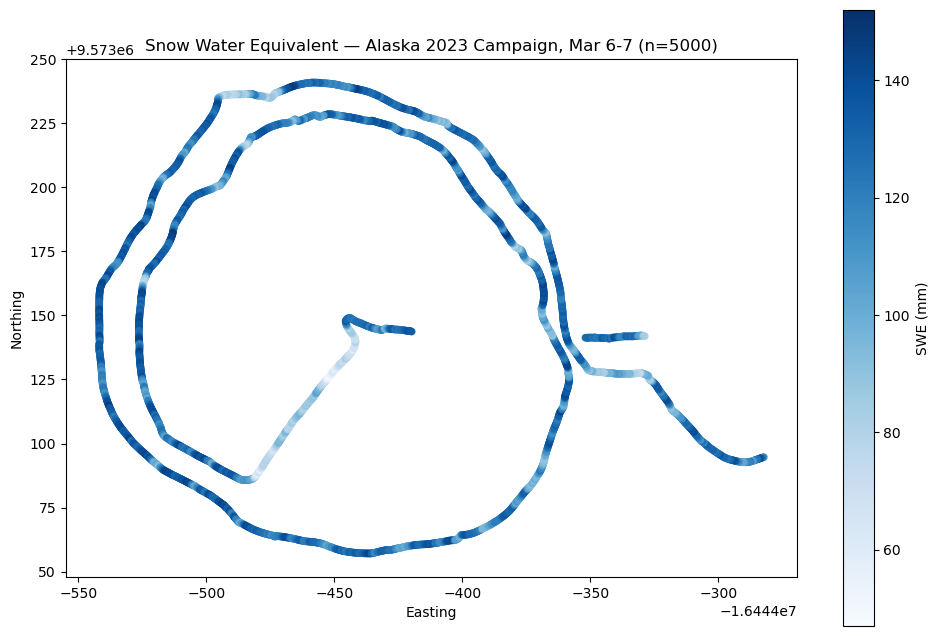

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
df_swe.to_crs(epsg=3857).plot(
    ax=ax,
    column='value',
    cmap='Blues',
    markersize=20,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'SWE (mm)', 'shrink': 0.8},
)
#ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.6)
ax.set_title(f'Snow Water Equivalent — Alaska 2023 Campaign, Mar 7-8 (n={len(df_swe)})')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
plt.tight_layout()
plt.show()

## Resources and references

- [snowexsql on GitHub](https://github.com/SnowEx/snowexsql)
- [SnowEx Field Campaigns Overview](snowex_data_overview.ipynb) — background on what data was collected and where
- [GeoPandas documentation](https://geopandas.org/en/stable/)
- [Shapely documentation](https://shapely.readthedocs.io/)
- [contextily documentation](https://contextily.readthedocs.io/)